In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
wine_data = load_wine()

df = pd.DataFrame(data=wine_data.data, columns=wine_data.feature_names)
df['wine_class'] = wine_data.target
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [6]:
print(df.shape)
print(df.columns)

df.info()
df.describe().T

(178, 14)
Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'wine_class'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df_cleaning = df.copy()

df_cleaning.loc[0, "alcohol"] = np.nan
df_cleaning.loc[3, "malic_acid"] = np.nan

df_cleaning.isnull().sum()

df_cleaning["alcohol"] = df_cleaning["alcohol"].fillna(df_cleaning["alcohol"].mean())
df_cleaning["malic_acid"] = df_cleaning["malic_acid"].fillna(df_cleaning["malic_acid"].mean())

df_cleaning.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
wine_class                      0
dtype: int64

In [11]:
X = df_cleaning.drop("wine_class", axis=1)
y = df_cleaning["wine_class"]

X.head()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,0.000000,-5.644010e-01,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.256546,-5.015432e-01,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.206810,1.927842e-02,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.711315,3.987780e-16,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.306282,2.258111e-01,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [14]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled_df)

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['wine_class'] = y
pca_df.head()

,PC1,PC2,wine_class
0,3.098013,0.717745,0
1,2.211684,-0.317282,0
2,2.517920,1.050442,0
3,3.661582,2.865750,0
4,1.008845,0.877420,0


In [17]:
pca_components = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=X.columns)
pca_components

,PC1,PC2
alcohol,0.137809,0.484787
malic_acid,-0.244462,0.226583
ash,-0.002732,0.315754
alcalinity_of_ash,-0.239240,-0.011494
magnesium,0.141125,0.297131
total_phenols,0.395026,0.068588
flavanoids,0.423570,-0.000217
nonflavanoid_phenols,-0.299029,0.026607
proanthocyanins,0.313796,0.040641
color_intensity,-0.090355,0.529365


In [ ]:
print(pca.explained_variance_ratio_) # The perceentage of information each principal component holds after the transformation. The sum of the explained variance ratio should be equal to 1.0, which means that all the information in the original dataset is preserved in the transformed dataset.
print(pca.explained_variance_ratio_.sum())

[0.36122498 0.19216969]
0.5533946718043679


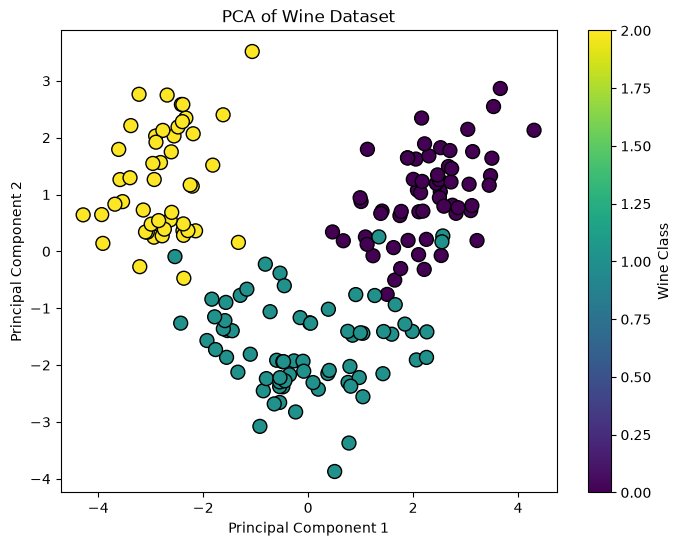

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['wine_class'], cmap='viridis', edgecolor='k', s=100)
plt.title('PCA of Wine Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Wine Class')
plt.show()